In [1]:
import pandas as pd
import matplotlib.pyplot as plt

PERIOD = "2020_2024"

events_df = pd.read_csv(
    f"../outputs/makueni_vegetation_response_recovery_{PERIOD}.csv"
)

date_columns = [
    "event_start",
    "event_end",
    "baseline_start",
    "minimum_ndvi_month",
    "recovery_month"
]

for column in date_columns:
    events_df[column] = pd.to_datetime(
        events_df[column],
        errors="coerce"
    )

events_df

,drought_event_id,event_start,event_end,duration_months,baseline_start,baseline_ndvi,minimum_ndvi,minimum_ndvi_month,ndvi_decline,ndvi_decline_pct,recovery_threshold,recovery_month,recovery_time_months,recovered_within_window
0,1,2020-08-01,2020-09-01,2,2020-05-01,0.398765,0.197690,2020-09-01,0.201075,50.424370,0.358889,2020-12-01,3.0,True
1,2,2021-06-01,2021-06-01,1,2021-03-01,0.252980,0.157697,2021-09-01,0.095284,37.664413,0.227682,2021-12-01,3.0,True
2,3,2021-09-01,2021-09-01,1,2021-06-01,0.279649,0.157697,2021-09-01,0.121952,43.609028,0.251684,2021-12-01,3.0,True
3,4,2022-06-01,2022-09-01,4,2022-03-01,0.308229,0.129706,2022-11-01,0.178522,57.918799,0.277406,2022-12-01,1.0,True
4,5,2023-02-01,2023-02-01,1,2022-11-01,0.359173,0.217837,2023-08-01,0.141336,39.350495,0.323256,NaT,NaN,False
5,6,2023-07-01,2023-09-01,3,2023-04-01,0.350630,0.170202,2023-10-01,0.180428,51.458210,0.315567,2023-11-01,1.0,True
6,7,2024-06-01,2024-06-01,1,2024-03-01,0.461690,0.214911,2024-11-01,0.246780,53.451342,0.415521,2024-12-01,1.0,True
7,8,2024-08-01,2024-09-01,2,2024-05-01,0.430214,0.214911,2024-11-01,0.215304,50.045668,0.387193,2024-12-01,1.0,True


In [2]:
impact_events_df = events_df[
    events_df["ndvi_decline"] > 0
].copy()

impact_events_df[
    [
        "drought_event_id",
        "event_start",
        "event_end",
        "duration_months",
        "ndvi_decline_pct",
        "recovery_time_months",
        "recovered_within_window"
    ]
]

,drought_event_id,event_start,event_end,duration_months,ndvi_decline_pct,recovery_time_months,recovered_within_window
0,1,2020-08-01,2020-09-01,2,50.424370,3.0,True
1,2,2021-06-01,2021-06-01,1,37.664413,3.0,True
2,3,2021-09-01,2021-09-01,1,43.609028,3.0,True
3,4,2022-06-01,2022-09-01,4,57.918799,1.0,True
4,5,2023-02-01,2023-02-01,1,39.350495,NaN,False
5,6,2023-07-01,2023-09-01,3,51.458210,1.0,True
6,7,2024-06-01,2024-06-01,1,53.451342,1.0,True
7,8,2024-08-01,2024-09-01,2,50.045668,1.0,True


In [3]:
total_candidate_events = len(events_df)

vegetation_impact_events = len(impact_events_df)

recovered_events = impact_events_df[
    impact_events_df["recovered_within_window"] == True
].copy()

recovery_rate_pct = (
    len(recovered_events)
    / vegetation_impact_events
    * 100
    if vegetation_impact_events > 0
    else None
)

mean_drought_duration = (
    events_df["duration_months"].mean()
)

mean_ndvi_decline_pct = (
    impact_events_df["ndvi_decline_pct"].mean()
)

median_ndvi_decline_pct = (
    impact_events_df["ndvi_decline_pct"].median()
)

maximum_ndvi_decline_pct = (
    impact_events_df["ndvi_decline_pct"].max()
)

mean_recovery_time = (
    recovered_events["recovery_time_months"].mean()
)

median_recovery_time = (
    recovered_events["recovery_time_months"].median()
)

maximum_recovery_time = (
    recovered_events["recovery_time_months"].max()
)

In [4]:
resilience_profile = pd.DataFrame(
    [
        {
            "study_area": "Makueni County",
            "period": PERIOD,
            "candidate_drought_events": total_candidate_events,
            "vegetation_impact_events": vegetation_impact_events,
            "mean_drought_duration_months": mean_drought_duration,
            "mean_ndvi_decline_pct": mean_ndvi_decline_pct,
            "median_ndvi_decline_pct": median_ndvi_decline_pct,
            "maximum_ndvi_decline_pct": maximum_ndvi_decline_pct,
            "recovered_events": len(recovered_events),
            "recovery_rate_pct": recovery_rate_pct,
            "mean_recovery_time_months": mean_recovery_time,
            "median_recovery_time_months": median_recovery_time,
            "maximum_recovery_time_months": maximum_recovery_time
        }
    ]
)

resilience_profile

,study_area,period,candidate_drought_events,vegetation_impact_events,mean_drought_duration_months,mean_ndvi_decline_pct,median_ndvi_decline_pct,maximum_ndvi_decline_pct,recovered_events,recovery_rate_pct,mean_recovery_time_months,median_recovery_time_months,maximum_recovery_time_months
0,Makueni County,2020_2024,8,8,1.875,47.99029,50.235019,57.918799,7,87.5,1.857143,1.0,3.0


In [5]:
resilience_profile.to_csv(
    f"../outputs/makueni_resilience_profile_{PERIOD}.csv",
    index=False
)

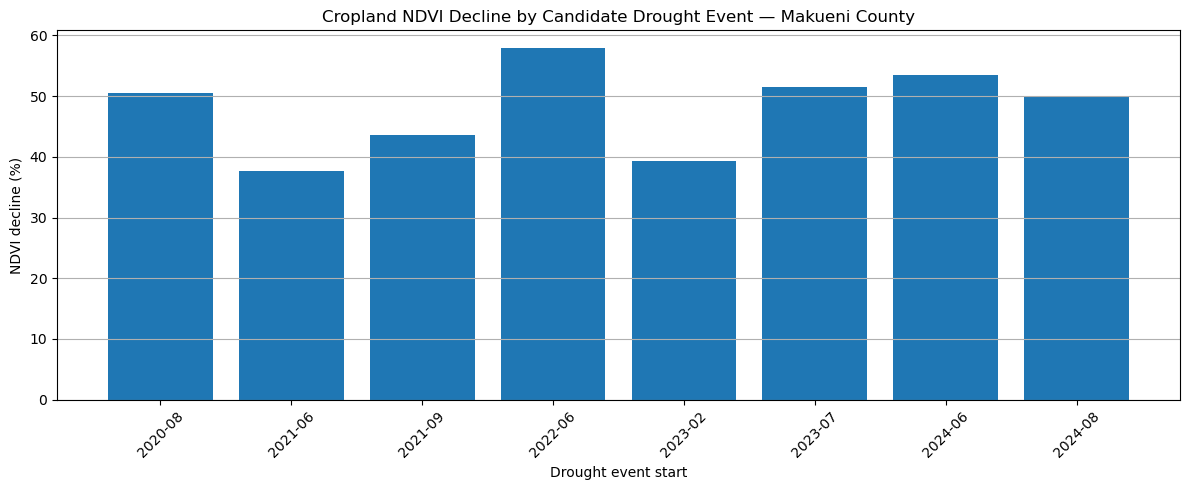

In [6]:
plot_df = impact_events_df.sort_values(
    "event_start"
).copy()

plot_df["event_label"] = (
    plot_df["event_start"]
    .dt.strftime("%Y-%m")
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    plot_df["event_label"],
    plot_df["ndvi_decline_pct"]
)

ax.set_title(
    "Cropland NDVI Decline by Candidate Drought Event — Makueni County"
)

ax.set_xlabel("Drought event start")
ax.set_ylabel("NDVI decline (%)")
ax.grid(axis="y")

plt.xticks(rotation=45)

fig.tight_layout()

fig.savefig(
    f"../docs/images/makueni_ndvi_decline_by_event_{PERIOD}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

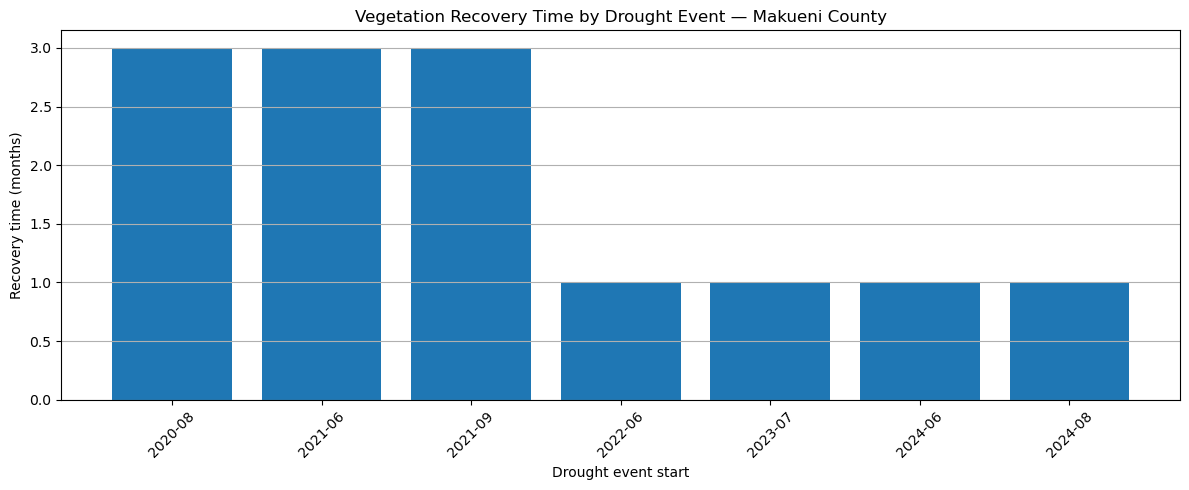

In [7]:
recovery_plot_df = recovered_events.sort_values(
    "event_start"
).copy()

recovery_plot_df["event_label"] = (
    recovery_plot_df["event_start"]
    .dt.strftime("%Y-%m")
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    recovery_plot_df["event_label"],
    recovery_plot_df["recovery_time_months"]
)

ax.set_title(
    "Vegetation Recovery Time by Drought Event — Makueni County"
)

ax.set_xlabel("Drought event start")
ax.set_ylabel("Recovery time (months)")
ax.grid(axis="y")

plt.xticks(rotation=45)

fig.tight_layout()

fig.savefig(
    f"../docs/images/makueni_recovery_time_by_event_{PERIOD}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
if not impact_events_df.empty:
    most_severe_event = impact_events_df.loc[
        impact_events_df["ndvi_decline_pct"].idxmax()
    ]

    print("Most severe event:")
    print("Event ID:", most_severe_event["drought_event_id"])
    print("Start:", most_severe_event["event_start"])
    print("End:", most_severe_event["event_end"])
    print(
        "NDVI decline (%):",
        most_severe_event["ndvi_decline_pct"]
    )

Most severe event:
Event ID: 4
Start: 2022-06-01 00:00:00
End: 2022-09-01 00:00:00
NDVI decline (%): 57.91879869587797


In [9]:
if not recovered_events.empty:
    slowest_recovery = recovered_events.loc[
        recovered_events["recovery_time_months"].idxmax()
    ]

    print("Slowest recovery:")
    print("Event ID:", slowest_recovery["drought_event_id"])
    print("Start:", slowest_recovery["event_start"])
    print(
        "Recovery time (months):",
        slowest_recovery["recovery_time_months"]
    )

Slowest recovery:
Event ID: 1
Start: 2020-08-01 00:00:00
Recovery time (months): 3.0


In [10]:
print("Makueni resilience profile")
print("---------------------------")

print(
    "Candidate drought events:",
    total_candidate_events
)

print(
    "Events with vegetation decline:",
    vegetation_impact_events
)

print(
    "Mean NDVI decline (%):",
    round(mean_ndvi_decline_pct, 2)
    if pd.notna(mean_ndvi_decline_pct)
    else "N/A"
)

print(
    "Mean recovery time (months):",
    round(mean_recovery_time, 2)
    if pd.notna(mean_recovery_time)
    else "N/A"
)

print(
    "Recovery rate (%):",
    round(recovery_rate_pct, 2)
    if recovery_rate_pct is not None
    else "N/A"
)

Makueni resilience profile
---------------------------
Candidate drought events: 8
Events with vegetation decline: 8
Mean NDVI decline (%): 47.99
Mean recovery time (months): 1.86
Recovery rate (%): 87.5
